In [3]:
!pip install torchvision
!pip install pillow

In [1]:
import torch
import os
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms
from PIL import Image

In [56]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

class ImageProcessor(Dataset):
    def __init__(self, root_dir_path, transformation=None):
        self.root_dir_path = root_dir_path
        self.transformation = transformation
        self.all_img_paths = [
            os.path.join(root_dir_path, img)
            for img in os.listdir(root_dir_path)
            if img.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformation:
            img = self.transformation(img)

        return img

In [69]:
root_dir_path="./img_align_celeba"

transformations = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    
])

In [70]:
dataset=ImageProcessor(root_dir_path,transformations)
print(f"loaded {len(dataset)} images")

loaded 10688 images


In [71]:
dataloader=DataLoader(dataset,batch_size=128,shuffle=True)

# Generator Network

In [72]:
import torch.nn as nn
class Generator(nn.Module):
    def __init__(self,z_dim=100,img_channels=3):
        super(Generator,self).__init__()

        #fully connected (dense) layers
        self.model =nn.Sequential(
            nn.Linear(z_dim,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,1024),
            nn.ReLU(),

            nn.Linear(1024,64 * 64 * img_channels),
            nn.Tanh(),
           
        )

    def forward(self,z):
        img=self.model(z)
        img=img.view(img.size(0),3,64,64)
        return img

## discriminator network

In [73]:
class Discriminator(nn.Module):
    def __init__(self,img_channels=3):
        super(Discriminator,self).__init__()

        #fully connected (dense) layers
        self.model =nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_channels *64*64,1024),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(1024,512),
            nn.LeakyReLU(),

            nn.Linear(512,256),
            nn.LeakyReLU(),

            nn.Linear(256,1),
            nn.Sigmoid(),
           
        )

    def forward(self,img):
        img=self.model(img)
        return img

In [74]:
import torch.optim as optim
GAN_loss=nn.BCELoss()

generator=Generator()
g_optimizer=optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.9999))

discriminator=Discriminator()
d_optimizer=optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.9999))

In [75]:
#device
import torch
if torch.backends.mps.is_available():
    device=torch.device("mps")
elif torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")

print(f"device is {device}")

device is cuda


In [76]:
generator=generator.to(device)
discriminator=discriminator.to(device)

In [77]:
def train(generator, discriminator, dataloader, epochs=10):
    generator.train()
    discriminator.train()

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            # Real and fake labels
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # ----------------------
            # Train Discriminator
            # ----------------------
            d_optimizer.zero_grad()

            noise = torch.randn(batch_size, 100).to(device)
            fake_imgs = generator(noise)

            real_output = discriminator(real_imgs)
            fake_output = discriminator(fake_imgs.detach())

            real_loss = GAN_loss(real_output, real_labels)
            fake_loss = GAN_loss(fake_output, fake_labels)

            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            d_optimizer.step()

            # ----------------------
            # Train Generator
            # ----------------------
            g_optimizer.zero_grad()

            fake_output = discriminator(fake_imgs)
            g_loss = GAN_loss(fake_output, real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(f"Epoch: {epoch}/{epochs}, Batch: {i}, G-loss: {g_loss.item():.4f}, D-loss: {d_loss.item():.4f}")

        save_generated_images(generator, epoch, device)

In [66]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [84]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torch

def save_generated_images(generator, epoch, device, num_imgs=8):

    generator.eval()

    with torch.no_grad():

        noise = torch.randn(num_imgs, 100).to(device)

        generated_imgs = generator(noise)

        grid = torchvision.utils.make_grid(
            generated_imgs,
            nrow=4,
            normalize=True
        )

        plt.figure(figsize=(8,8))

        plt.imshow(
            np.transpose(grid.cpu(), (1,2,0))
        )

        plt.title(f"Epoch {epoch+1}")

        plt.axis("off")

        plt.show()

    generator.train()

Epoch: 0/5, Batch: 0, G-loss: 1.8437, D-loss: 0.1948
Epoch: 0/5, Batch: 50, G-loss: 0.6462, D-loss: 0.5526


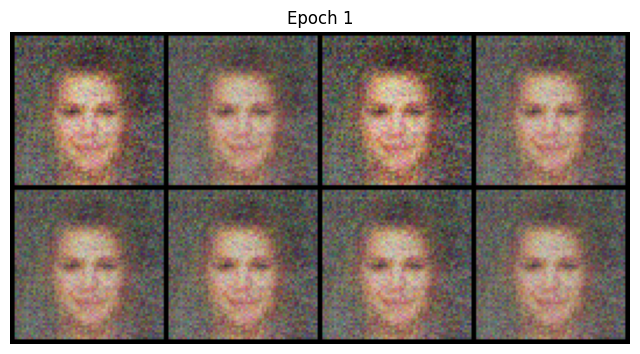

Epoch: 1/5, Batch: 0, G-loss: 2.0723, D-loss: 0.1685
Epoch: 1/5, Batch: 50, G-loss: 2.0627, D-loss: 0.1287


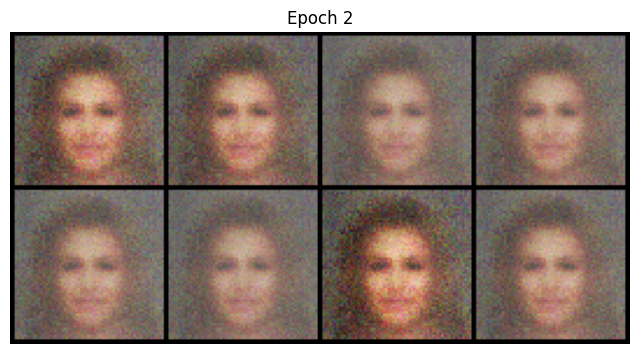

Epoch: 2/5, Batch: 0, G-loss: 2.3118, D-loss: 0.2088
Epoch: 2/5, Batch: 50, G-loss: 2.7899, D-loss: 0.0928


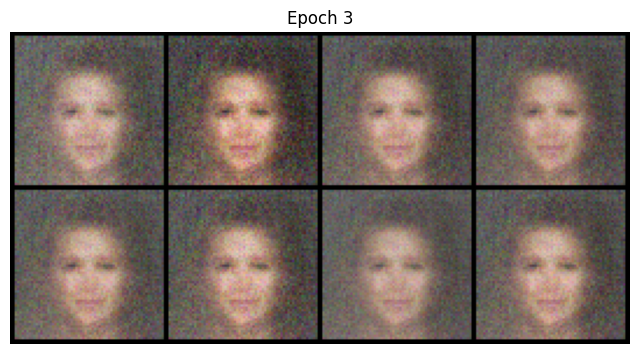

Epoch: 3/5, Batch: 0, G-loss: 3.0006, D-loss: 0.0553
Epoch: 3/5, Batch: 50, G-loss: 3.3265, D-loss: 0.1858


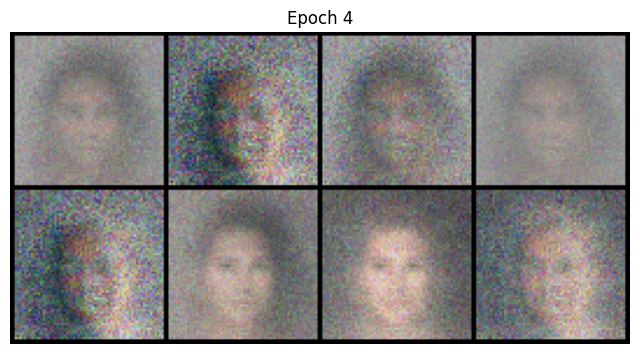

Epoch: 4/5, Batch: 0, G-loss: 0.4349, D-loss: 0.3845
Epoch: 4/5, Batch: 50, G-loss: 2.6157, D-loss: 0.2082


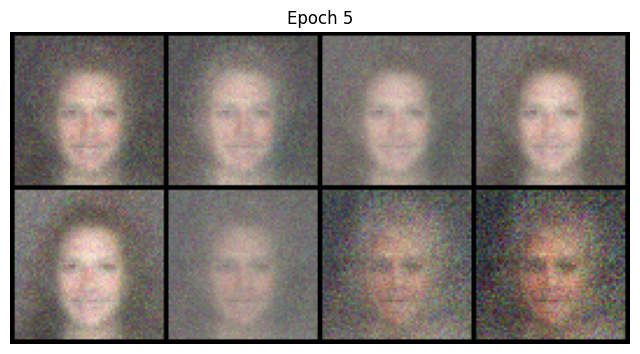

In [85]:
train(generator,discriminator,dataloader,epochs=5)